In [2]:
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-i162ugxz
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-i162ugxz
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit ef028547ff4459f6e98fe429d1564bd1d513fc31
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.7.0-py3-none-any.whl size=1168744 sha256=3dff515e68c24b64a4faab94b2d8fac37e0968b79763f9b93240e860d2442625
  Stored in directory: /tmp/pip-ephem-wheel-cache-9ns0_sou/wheels/d3/78/eb/9e26525b948d19533f1688fb6c209cec8a0ba793d39b49ae8f
Successfully built torch-geometric


### **Loading libraries**

I imported PyTorch and PyTorch Geometric libraries, which are used for graph neural networks (GNNs).

In [51]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

### **Loading dataset**

I loaded the Cora dataset, which is a citation network where each node represents a paper, and edges represent citations.The NormalizeFeatures transform normalizes the features of the nodes.

In [44]:
import torch
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T


dataset = Planetoid(root='data/Planetoid', name='Cora', transform=T.NormalizeFeatures())

data = dataset[0]


print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Node features shape: {data.x.shape}")
print(f"Node labels shape: {data.y.shape}")
print(f"Edge index shape: {data.edge_index.shape}")



Number of nodes: 2708
Number of edges: 10556
Node features shape: torch.Size([2708, 1433])
Node labels shape: torch.Size([2708])
Edge index shape: torch.Size([2, 10556])


### **Plotting the dataset**

networkx: A library I use for creating, manipulating, and studying complex networks

matplotlib.pyplot: A plotting library I use to visualize the graph.

edge_index: I convert the edge_index (from the Cora dataset) into a NumPy array.

edge_list: I create the edge list by zipping together the source and target nodes edge_index

I create a Graph object using networkx

I use networkx's draw function to plot the graph

<ipython-input-45-f29c04839e79>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10', 7)
/usr/local/lib/python3.10/dist-packages/networkx/drawing/nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


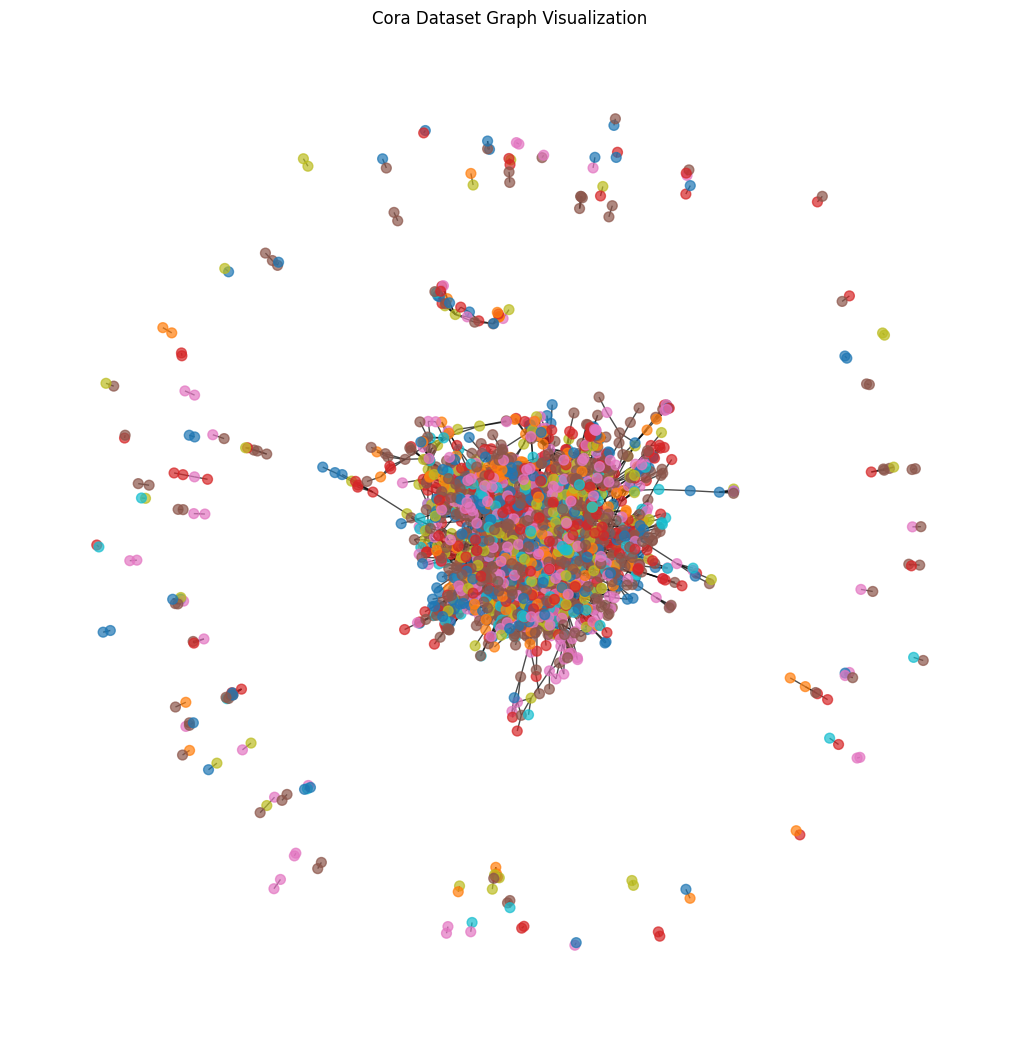

In [45]:
import networkx as nx
import matplotlib.pyplot as plt
edge_index = data.edge_index.numpy()
edge_list = list(zip(edge_index[0], edge_index[1]))


G = nx.Graph()
G.add_edges_from(edge_list)

node_labels = data.y.numpy()

color_map = plt.cm.get_cmap('tab10', 7)
colors = [color_map(label) for label in node_labels]


plt.figure(figsize=(10, 10))
nx.draw(G, node_size=50, node_color=colors, with_labels=False, cmap=color_map, alpha=0.7, font_size=10)
plt.title("Cora Dataset Graph Visualization")
plt.show()

### **Extracting the mask for each set and printing them**

 I extract the mask for the training, validation and test set. It is a boolean tensor where True indicates a node is part of the training,validation or test set.

In [46]:
train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask


print(f"Training nodes: {train_mask.sum().item()}")
print(f"Validation nodes: {val_mask.sum().item()}")
print(f"Test nodes: {test_mask.sum().item()}")

Training nodes: 140
Validation nodes: 500
Test nodes: 1000


### **Extracting the size of each matrix related to dataset**

I extract the feature matrix, where each row represents the features of a node. These features describe the properties of the nodes,labels of the nodes, which represent the class or category of each node,edge index, which defines the structure of the graph. It contains pairs of nodes, representing edges between them.

In [47]:
features = data.x
labels = data.y
edges = data.edge_index
print(f"Feature matrix shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Edge index shape: {edges.shape}")
print(f"Node 0 features: {features[0]}")
print(f"Node 0 label: {labels[0]}")

Feature matrix shape: torch.Size([2708, 1433])
Labels shape: torch.Size([2708])
Edge index shape: torch.Size([2, 10556])
Node 0 features: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Node 0 label: 3


I build the model using pytorch.

you may ask why I pass the whole data instead of the training set.In GNN unlike FNN because of the connectivity between the nodes we should pass all of our data to the network.note that still the loss is computed regarding the training nodes.

In [52]:
import torch_geometric.nn as pyg_nn
import torch_geometric.transforms as T
import torch.nn as nn
from torch_geometric.datasets import Planetoid
class GCN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCN, self).__init__()
        torch.manual_seed(1234567)
        self.conv1 = pyg_nn.GCNConv(in_channels, 16)
        self.conv2 = pyg_nn.GCNConv(16, out_channels)

    def forward(self, data):

        x = self.conv1(data.x, data.edge_index)
        x = torch.relu(x)

        x = self.conv2(x, data.edge_index)
        return x

First my optimizer didn't have weight decay and the loss was equal to nan.because at that time because the model lacked the regularization term that helped control the training process.

In [49]:
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import accuracy_score



def train(model, data, optimizer, criterion):

    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


def test(model, data):
    model.eval()
    out = model(data)

    pred = out.argmax(dim=1)
    train_acc = accuracy_score(data.y[data.train_mask].cpu(), pred[data.train_mask].cpu())
    val_acc = accuracy_score(data.y[data.val_mask].cpu(), pred[data.val_mask].cpu())
    test_acc = accuracy_score(data.y[data.test_mask].cpu(), pred[data.test_mask].cpu())
    return train_acc, val_acc, test_acc


model = GCN(in_channels=dataset.num_features, out_channels=dataset.num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()


epochs = 200
for epoch in range(epochs):
    loss = train(model, data, optimizer, criterion)
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test(model, data)
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')


Epoch: 000, Loss: 1.9464, Train Acc: 0.3500, Val Acc: 0.2660, Test Acc: 0.2680
Epoch: 010, Loss: 1.8422, Train Acc: 0.5643, Val Acc: 0.3740, Test Acc: 0.3750
Epoch: 020, Loss: 1.6769, Train Acc: 0.8357, Val Acc: 0.5400, Test Acc: 0.5550
Epoch: 030, Loss: 1.4593, Train Acc: 0.9357, Val Acc: 0.6860, Test Acc: 0.6900
Epoch: 040, Loss: 1.2090, Train Acc: 0.9714, Val Acc: 0.7520, Test Acc: 0.7600
Epoch: 050, Loss: 0.9690, Train Acc: 0.9714, Val Acc: 0.7620, Test Acc: 0.7870
Epoch: 060, Loss: 0.7744, Train Acc: 0.9786, Val Acc: 0.7660, Test Acc: 0.8070
Epoch: 070, Loss: 0.6319, Train Acc: 0.9786, Val Acc: 0.7720, Test Acc: 0.8100
Epoch: 080, Loss: 0.5313, Train Acc: 0.9786, Val Acc: 0.7760, Test Acc: 0.8120
Epoch: 090, Loss: 0.4595, Train Acc: 0.9786, Val Acc: 0.7860, Test Acc: 0.8100
Epoch: 100, Loss: 0.4068, Train Acc: 0.9786, Val Acc: 0.7900, Test Acc: 0.8080
Epoch: 110, Loss: 0.3665, Train Acc: 0.9786, Val Acc: 0.7920, Test Acc: 0.8120
Epoch: 120, Loss: 0.3350, Train Acc: 0.9857, Val Acc